# Yanai-band momentum and energy flux — TPOSE24 (dt=60 run)

Momentum- and energy-flux diagnostics for the 15-40 day (Yanai) period band in
the TPOSE24 `oct2012_3mo_dt60_AB3` run (3-hourly output, 2012-10-01 onward).

**Fields:** UVEL, VVEL, WVEL, PHIHYD (hydrostatic pressure potential anomaly).

**Quantities**
- Perturbations `u',v',w',phi'` = 15-40 day band-pass of each field in time.
- Momentum flux (kinematic Reynolds stress, m² s⁻²): u'u', v'v', w'w', u'v', u'w', v'w'.
- Energy flux (pressure work, W m⁻²): F = ρ₀ φ' (u', v', w'), with ρ₀ = 1027 kg m⁻³.
- Vertical momentum-flux convergence (m s⁻²): −∂⟨u'w'⟩/∂z, −∂⟨v'w'⟩/∂z.

**Assumptions**
- Yanai band defined as 15-40 day periods; zero-phase 4th-order Butterworth band-pass.
- The model run starts on day 8: the first 8 days (spin-up) are never loaded and
  never enter the filter. After filtering, the first and last 20 days of the
  filtered signal are dropped (band-pass edge contamination), leaving the analysis
  window ~2012-10-29 to 2012-12-09.
- Profiles at 140°W (the only requested longitude inside the domain) and
  latitudes 1°S, 0°N, 1°N, 2°N, 3°N.
- Maps compressed over depth (partial-cell weighted integral) and time (mean).
- WVEL averaged from cell top faces to cell centers before forming products; the
  C-grid horizontal half-cell stagger between U, V, φ is neglected.
- Z is irregularly spaced; vertical derivative uses np.gradient(·, Z).
- Background velocity profiles are the time mean of the (unfiltered) UVEL/VVEL over
  the same analysis window.

In [2]:
import sys, os
sys.path.append('/home/edavenport/analysis/motive-yanai-waves/scripts')
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import wave_filter as wf, fluxes as fx, tpose24_io as io

CACHE   = '/data/SO3/edavenport/tpose24/cache'
FIG_DIR = '/home/edavenport/analysis/motive-yanai-waves/figures'
os.makedirs(FIG_DIR, exist_ok=True)

prof  = xr.open_dataset(f'{CACHE}/yanai_profiles_dt60.nc')
# cov3d = xr.open_dataset(f'{CACHE}/yanai_flux_cov3d_dt60.nc')
# maps  = xr.open_dataset(f'{CACHE}/yanai_flux_maps_dt60.nc')

# Drop the first SPINUP_DAYS immediately, before any filtering, so the model
# spin-up never enters the band-pass (it would otherwise bleed into the signal).
_cut = np.datetime64(io.REF_DATE) + np.timedelta64(int(io.SPINUP_DAYS*86400), 's')
prof = prof.isel(time=prof['time'].values > _cut)     # post-spin-up = filter input

LOCS = [str(x) for x in prof['loc'].values]           # 1S,0N,1N,2N,3N
Z    = prof['depth'].values                           # cell-center depth (m, <0)
drF  = prof['drF'].values
hFac = prof['hFacC'].values                           # (loc, depth)

# After filtering, keep only the interior: drop the first/last EDGE_TRIM_DAYS of
# the filtered signal (band-pass edge contamination near each record boundary).
time_ps = prof['time'].values                         # post-spin-up times
etm     = io.edge_trim_mask(time_ps)                  # interior-keeping mask
time    = time_ps[etm]                                # analysis time window
print('profile lon =', prof.attrs['lon'], 'E ;  lats =', prof['lat'].values)
print(f'filter input: {time_ps.size} steps after {io.SPINUP_DAYS}-day spin-up; '
      f'analysis window after {io.EDGE_TRIM_DAYS}-day edge trim: '
      f'{str(time[0])[:10]} to {str(time[-1])[:10]} ({time.size} steps)')

profile lon = 220.0207977294922 E ;  lats = [-0.9791667  -0.02083333  0.9791667   2.0208333   2.9791667 ]
filter input: 654 steps after 8.0-day spin-up; analysis window after 20.0-day edge trim: 2012-10-29 to 2012-12-09 (334 steps)


## Band-pass filtering and flux components at the profile columns

In [3]:
# 15-40 day band-pass of each post-spin-up field along time (axis 0), then keep
# the edge-trimmed interior (etm); columns -> (time, loc, depth)
def bp(name):
    return wf.bandpass(prof[name].values, axis=0)[etm]

up   = bp('UVEL')
vp   = bp('VVEL')
wp   = fx.w_to_center(bp('WVEL'), zaxis=-1)     # cell top faces -> centers
phip = bp('PHIHYD')

# instantaneous flux components (time, loc, depth)
flux = fx.momentum_fluxes(up, vp, wp)           # uu,vv,ww,uv,uw,vw  (m^2 s^-2)
flux.update(fx.energy_fluxes(phip, up, vp, wp)) # pu,pv,pw           (W m^-2)

# time-mean profiles and standard deviation over the analysis window (loc, depth)
fmean = {k: np.nanmean(v, axis=0) for k, v in flux.items()}
fstd  = {k: np.nanstd(v,  axis=0) for k, v in flux.items()}

# vertical convergence of the vertical momentum fluxes (loc, depth), m s^-2
conv = {k: fx.vertical_convergence(fmean[k], Z, zaxis=-1) for k in ('uw', 'vw')}

# background (unfiltered) time-mean velocity over the same window (loc, depth), m/s
Ubg = np.nanmean(prof['UVEL'].values[etm], axis=0)
Vbg = np.nanmean(prof['VVEL'].values[etm], axis=0)

# full-column, partial-cell-weighted depth integral of an instantaneous flux
def depth_integral(fld):                        # fld (time, loc, depth) -> (time, loc)
    thick = drF[None, None, :] * hFac[None, :, :]
    w = np.where(np.isfinite(fld), thick, 0.0)
    return np.sum(np.where(np.isfinite(fld), fld, 0.0) * w, axis=-1)

## (a) Time series

Full-column depth-integrated instantaneous Yanai-band fluxes at each latitude
(140°W), and depth-time sections of the vertical fluxes.

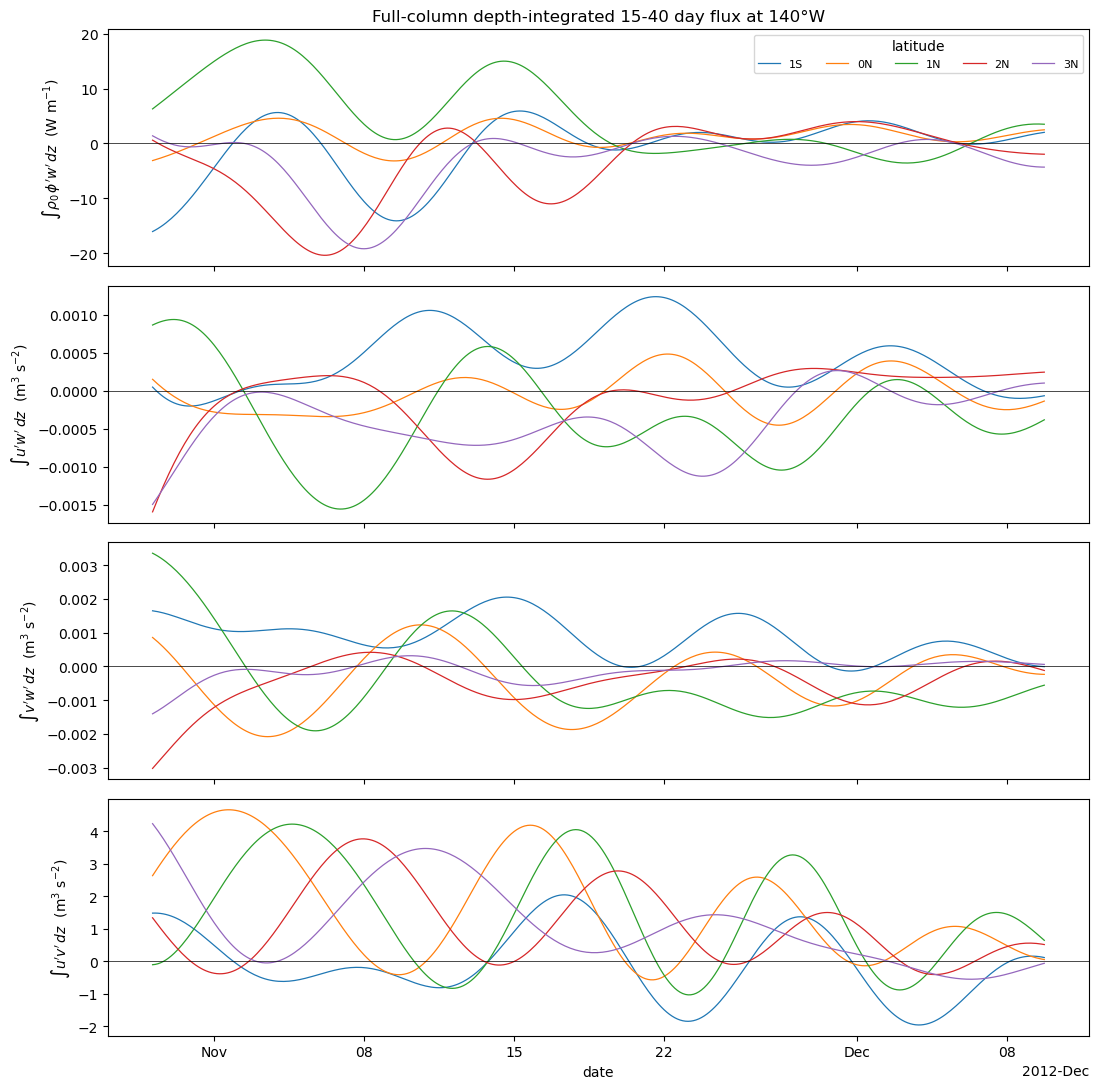

In [4]:
fig, axes = plt.subplots(4, 1, figsize=(11, 11), sharex=True)
ts = {k: depth_integral(flux[k]) for k in ('pw', 'uw', 'vw', 'uv')}
labels = {'pw': r"$\int \rho_0\,\phi' w'\,dz$  (W m$^{-1}$)",
          'uw': r"$\int u'w'\,dz$  (m$^3$ s$^{-2}$)",
          'vw': r"$\int v'w'\,dz$  (m$^3$ s$^{-2}$)",
          'uv': r"$\int u'v'\,dz$  (m$^3$ s$^{-2}$)"}
for ax, k in zip(axes, ('pw', 'uw', 'vw', 'uv')):
    for li, L in enumerate(LOCS):
        ax.plot(time, ts[k][:, li], lw=0.9, label=L)
    ax.axhline(0, color='k', lw=0.5)
    ax.set_ylabel(labels[k])
axes[0].legend(ncol=5, fontsize=8, loc='upper right', title='latitude')
_loc = mdates.AutoDateLocator(maxticks=8)
axes[-1].xaxis.set_major_locator(_loc)
axes[-1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(_loc))
axes[-1].set_xlabel('date')
axes[0].set_title('Full-column depth-integrated 15-40 day flux at 140°W')
fig.tight_layout(); fig.savefig(f'{FIG_DIR}/a1_flux_timeseries.png', dpi=140)

/tmp/ipykernel_3353671/2506753702.py:11: UserWarning: The following kwargs were not used by contour: 'shading'
  m = ax.contourf(time, Z, flux[k][:, c, :].T, cmap='RdBu_r',


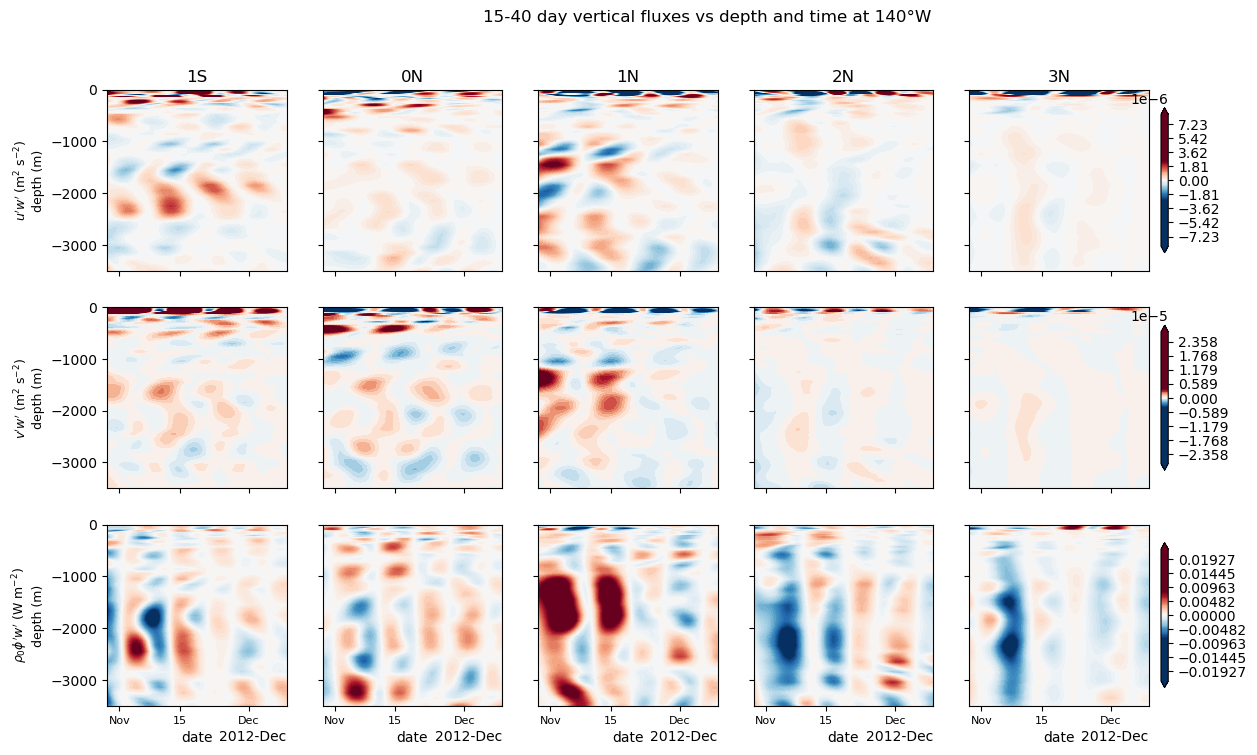

In [ ]:
# depth-time sections (Hovmoller) of the vertical fluxes at each latitude
comps_ts = [('uw', r"$u'w'$ (m$^2$ s$^{-2}$)", np.nanpercentile(np.abs(flux['uw']), 90)),
            ('vw', r"$v'w'$ (m$^2$ s$^{-2}$)", np.nanpercentile(np.abs(flux['vw']), 90)),
            ('pw', r"$\rho_0\phi' w'$ (W m$^{-2}$)", np.nanpercentile(np.abs(flux['pw']), 99))]
fig, axes = plt.subplots(len(comps_ts), len(LOCS), figsize=(16, 8),
                         sharex=True, sharey=True)
for r, (k, lab, v98) in enumerate(comps_ts):
    for c, L in enumerate(LOCS):
        ax = axes[r, c]
        levels = np.linspace(-v98, v98, 151)
        m = ax.contourf(time, Z, flux[k][:, c, :].T, cmap='RdBu_r',
                          levels=levels, extend='both', shading='auto')
        if r == 0: ax.set_title(L)
        if c == 0: ax.set_ylabel(lab + '\ndepth (m)', fontsize=9)
        ax.set_ylim(-3500, 0)
    fig.colorbar(m, ax=axes[r, :].tolist(), shrink=0.8, pad=0.01)
for ax in axes[-1]:                          # legible, non-overlapping date ticks
    loc = mdates.AutoDateLocator(maxticks=6)
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
    ax.tick_params(axis='x', labelsize=8)
    ax.set_xlabel('date')
fig.suptitle('15-40 day vertical fluxes vs depth and time at 140°W')
fig.savefig(f'{FIG_DIR}/a2_flux_hovmoller.png', dpi=140, bbox_inches='tight')

## (b) Mean profiles with standard deviation

Per latitude (columns): background time-mean velocity, mean momentum-flux
components ±1σ, vertical momentum-flux convergence, and mean vertical energy
flux ±1σ. Three versions are drawn from the same data: full depth (linear),
a 0-1500 m depth zoom (linear), and full depth on a log depth axis.

In [ ]:
def _linthresh(*arrs, ratio=1e-3):
    """symlog linear-threshold: `ratio` of the largest |value| across arrs."""
    v = np.concatenate([np.abs(a[np.isfinite(a)]).ravel() for a in arrs])
    mx = v.max() if v.size else 1.0
    return max(mx * ratio, 1e-15)

def _crop_x(ax, frac, pairs):
    """Crop symmetric x-limits to `frac` of the data extent (|mean|+std), so
    small deep values are magnified and large shallow values clip off-panel."""
    ext = max(np.nanmax(np.abs(m) + (0.0 if s is None else s)) for m, s in pairs)
    ax.set_xlim(-frac * ext, frac * ext)

def _tidy_xaxis(ax, symlog=False, lt=None):
    """Keep x tick labels legible: few ticks, small rotated font."""
    if symlog:
        ax.set_xscale('symlog', linthresh=lt, linscale=0.5)
        ax.xaxis.set_major_locator(mticker.SymmetricalLogLocator(
            linthresh=lt, base=100, subs=(1.0,)))
    else:
        ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=4))
        ax.ticklabel_format(axis='x', style='sci', scilimits=(-2, 2))
        ax.xaxis.get_offset_text().set_fontsize(7)
    ax.tick_params(axis='x', labelsize=7, rotation=30)

# u'w' & v'w' share a row; u'v' is drawn on its own row (much larger magnitude)
def profile_panels(symlog=False, zoom=None, xcrop=None, fname=None, suffix=''):
    """5-row (velocity; u'w' & v'w'; u'v'; convergence; energy flux) x 5-latitude
    profile figure over depth Z. symlog -> symmetric-log flux axis on the flux
    rows (highlights small deep signals); zoom=(top,bot) m -> linear depth zoom;
    xcrop (0-1) -> crop flux x-limits to that fraction of the data extent."""
    fig, axes = plt.subplots(5, len(LOCS), figsize=(16, 15), sharey=True)
    for c, L in enumerate(LOCS):
        # row 0: background velocity (always linear)
        ax = axes[0, c]
        ax.plot(Ubg[c], Z, label='u'); ax.plot(Vbg[c], Z, label='v')
        ax.axvline(0, color='k', lw=0.5); ax.set_title(L)
        _tidy_xaxis(ax)
        if c == 0: ax.set_ylabel('time-mean velocity (m s$^{-1}$)\ndepth (m)')
        if c == len(LOCS)-1: ax.legend(fontsize=8)
        # row 1: vertical momentum fluxes u'w', v'w' +/- 1 sigma
        ax = axes[1, c]
        for k, col in (('uw', 'C0'), ('vw', 'C1')):
            ax.plot(fmean[k][c], Z, col, label=k[0]+"'"+k[1]+"'")
            ax.fill_betweenx(Z, fmean[k][c]-fstd[k][c], fmean[k][c]+fstd[k][c],
                             color=col, alpha=0.15)
        ax.axvline(0, color='k', lw=0.5)
        _tidy_xaxis(ax, symlog, _linthresh(fmean['uw'][c], fmean['vw'][c]))
        if xcrop and not symlog:
            _crop_x(ax, xcrop, [(fmean['uw'][c], fstd['uw'][c]),
                                (fmean['vw'][c], fstd['vw'][c])])
        if c == 0: ax.set_ylabel(r"$\langle u'w'\rangle,\langle v'w'\rangle\pm1\sigma$"
                                 "\n(m$^2$ s$^{-2}$)\ndepth (m)")
        if c == len(LOCS)-1: ax.legend(fontsize=8)
        # row 2: horizontal momentum flux u'v' +/- 1 sigma (own axis scale)
        ax = axes[2, c]
        ax.plot(fmean['uv'][c], Z, 'C2', label="u'v'")
        ax.fill_betweenx(Z, fmean['uv'][c]-fstd['uv'][c], fmean['uv'][c]+fstd['uv'][c],
                         color='C2', alpha=0.15)
        ax.axvline(0, color='k', lw=0.5)
        _tidy_xaxis(ax, symlog, _linthresh(fmean['uv'][c]))
        if xcrop and not symlog:
            _crop_x(ax, xcrop, [(fmean['uv'][c], fstd['uv'][c])])
        if c == 0: ax.set_ylabel(r"$\langle u'v'\rangle\pm1\sigma$"
                                 "\n(m$^2$ s$^{-2}$)\ndepth (m)")
        if c == len(LOCS)-1: ax.legend(fontsize=8)
        # row 3: vertical momentum-flux convergence
        ax = axes[3, c]
        ax.plot(conv['uw'][c], Z, 'C0', label=r"$-\partial_z\langle u'w'\rangle$")
        ax.plot(conv['vw'][c], Z, 'C1', label=r"$-\partial_z\langle v'w'\rangle$")
        ax.axvline(0, color='k', lw=0.5)
        _tidy_xaxis(ax, symlog, _linthresh(conv['uw'][c], conv['vw'][c]))
        if xcrop and not symlog:
            _crop_x(ax, xcrop, [(conv['uw'][c], None), (conv['vw'][c], None)])
        if c == 0: ax.set_ylabel('mom.-flux convergence\n(m s$^{-2}$)\ndepth (m)')
        if c == len(LOCS)-1: ax.legend(fontsize=8)
        # row 4: mean vertical energy flux +/- 1 sigma
        ax = axes[4, c]
        ax.plot(fmean['pw'][c], Z, 'C3')
        ax.fill_betweenx(Z, fmean['pw'][c]-fstd['pw'][c], fmean['pw'][c]+fstd['pw'][c],
                         color='C3', alpha=0.15)
        ax.axvline(0, color='k', lw=0.5)
        _tidy_xaxis(ax, symlog, _linthresh(fmean['pw'][c]))
        if xcrop and not symlog:
            _crop_x(ax, xcrop, [(fmean['pw'][c], fstd['pw'][c])])
        if c == 0: ax.set_ylabel(r"$\langle\rho_0\phi' w'\rangle\pm1\sigma$"
                                 "\n(W m$^{-2}$)\ndepth (m)")
    axes[0, 0].set_ylim((-zoom[1], -zoom[0]) if zoom else (-3000, 0))
    fig.suptitle('15-40 day flux profiles and background velocity at 140°W'
                 + suffix, y=0.997)
    fig.tight_layout()
    if fname: fig.savefig(f'{FIG_DIR}/{fname}', dpi=140)
    return fig

# linear versions crop the flux x-axis to 30% of the data extent so small deep
# values are clear (large shallow values clip off-panel); symlog version does not
profile_panels(xcrop=0.30, fname='b_profiles.png',
               suffix=' (full depth, linear flux, x-axis cropped to 30%)')
profile_panels(zoom=(0, 1500), xcrop=0.30, fname='b_profiles_zoom_0-1500m.png',
               suffix=' (0-1500 m zoom, linear flux, x-axis cropped to 30%)')
profile_panels(symlog=True, fname='b_profiles_symlogflux.png',
               suffix=' (symlog flux axis)')

### Energy-flux component profiles

Mean profiles ±1σ of all three energy-flux components ρ₀φ'u', ρ₀φ'v', ρ₀φ'w'
(zonal, meridional, vertical pressure work) at each latitude.

In [ ]:
def energy_flux_profiles(fname='b_energy_flux_profiles.png', suffix=''):
    rows = [('pu', 'C0', r"$\langle\rho_0\phi' u'\rangle\pm1\sigma$"),
            ('pv', 'C1', r"$\langle\rho_0\phi' v'\rangle\pm1\sigma$"),
            ('pw', 'C3', r"$\langle\rho_0\phi' w'\rangle\pm1\sigma$")]
    fig, axes = plt.subplots(3, len(LOCS), figsize=(16, 10), sharey=True)
    for r, (k, col, lab) in enumerate(rows):
        for c, L in enumerate(LOCS):
            ax = axes[r, c]
            ax.plot(fmean[k][c], Z, col)
            ax.fill_betweenx(Z, fmean[k][c]-fstd[k][c], fmean[k][c]+fstd[k][c],
                             color=col, alpha=0.15)
            ax.axvline(0, color='k', lw=0.5); _tidy_xaxis(ax)
            if r == 0: ax.set_title(L)
            if c == 0: ax.set_ylabel(lab + '\n(W m$^{-2}$)\ndepth (m)')
    axes[0, 0].set_ylim(-3000, 0)
    fig.suptitle('15-40 day energy-flux component profiles at 140°W' + suffix, y=0.995)
    fig.tight_layout()
    if fname: fig.savefig(f'{FIG_DIR}/{fname}', dpi=140)
    return fig

energy_flux_profiles()

## (c) Maps — depth-integrated, time-mean flux

2D lat/lon maps of each flux component integrated over the layers
0-350 m, 350-700 m, 700-1500 m, 1500 m-bottom, and the full column.

In [ ]:
lon = maps['lon'].values; lat = maps['lat'].values
LAYERS = [str(x) for x in maps['layer'].values]
lon_p, lat_p = float(prof.attrs['lon']), prof['lat'].values

def map_grid(components, comp_labels, unit, fname, title, cmap='RdBu_r', diverging=True):
    nr, nc = len(components), len(LAYERS)
    fig, axes = plt.subplots(nr, nc, figsize=(3.0*nc, 2.6*nr),
                             sharex=True, sharey=True, squeeze=False)
    for r, comp in enumerate(components):
        row = maps['flux_int'].sel(component=comp).values      # (layer, y, x)
        v98 = np.nanpercentile(np.abs(row), 98)
        for c, lay in enumerate(LAYERS):
            ax = axes[r, c]
            if diverging:
                m = ax.pcolormesh(lon, lat, row[c], cmap=cmap,
                                  vmin=-v98, vmax=v98, shading='auto')
            else:
                m = ax.pcolormesh(lon, lat, row[c], cmap=cmap,
                                  vmin=0, vmax=v98, shading='auto')
            ax.axhline(0, color='k', lw=0.4)
            ax.plot(lon_p, lat_p, 'kx', ms=3)
            if r == 0: ax.set_title(lay, fontsize=9)
            if c == 0: ax.set_ylabel(comp_labels[r] + '\nlat', fontsize=9)
        fig.colorbar(m, ax=axes[r, :].tolist(), shrink=0.85, pad=0.01)
    for ax in axes[-1]: ax.set_xlabel('lon (°E)')
    fig.suptitle(title, y=1.0)
    fig.savefig(f'{FIG_DIR}/{fname}', dpi=140, bbox_inches='tight')
    return fig

In [ ]:
# Energy flux components: rho0 * phi' * (u', v', w')
map_grid(['pu', 'pv', 'pw'],
         [r"$\int\rho_0\phi' u'\,dz$", r"$\int\rho_0\phi' v'\,dz$",
          r"$\int\rho_0\phi' w'\,dz$"],
         'W m$^{-1}$', 'c1_energy_flux_maps.png',
         'Depth-integrated time-mean 15-40 day energy flux (W m$^{-1}$)')

In [ ]:
# Vertical momentum-flux components: u'w', v'w'
map_grid(['uw', 'vw'],
         [r"$\int u'w'\,dz$", r"$\int v'w'\,dz$"],
         'm$^3$ s$^{-2}$', 'c2_vertical_momflux_maps.png',
         'Depth-integrated time-mean 15-40 day vertical momentum flux (m$^3$ s$^{-2}$)')

In [ ]:
# Remaining momentum-flux components: u'v' (signed) and variances u'u',v'v',w'w'
map_grid(['uv'], [r"$\int u'v'\,dz$"], 'm$^3$ s$^{-2}$',
         'c3_uv_momflux_maps.png',
         'Depth-integrated time-mean 15-40 day u\'v\' momentum flux (m$^3$ s$^{-2}$)')
map_grid(['uu', 'vv', 'ww'],
         [r"$\int u'u'\,dz$", r"$\int v'v'\,dz$", r"$\int w'w'\,dz$"],
         'm$^3$ s$^{-2}$', 'c4_variance_maps.png',
         'Depth-integrated time-mean 15-40 day velocity variances (m$^3$ s$^{-2}$)',
         cmap='viridis', diverging=False)